In [4]:
import matplotlib.pyplot as plt
import numpy as np

import wandb

# Dataset to model mapping
DATASET_MODEL_MAP = {"CIFAR10": "CIFAR-10 - ResNet18"}

In [5]:
api = wandb.Api(timeout=120)

## Plot

In [6]:
import importlib
import os

import pandas as pd
import seaborn as sns

import comask.analysis.cost_model_validation as cmv

importlib.reload(cmv)


from comask.analysis.cost_model_validation import (
    build_grouped_summary_rows,
    build_summary_rows,
    validate_sweep_cost_model_grouped,
)

SWEEP_PATH = "ICDCS/FedCIFAR10/0c5fihgi"  # "ICDCS/FedCIFAR10/brbkcg9d"

GAMMA = 3
RHO = 0.5
MAX_ROUNDS = 100  # Set to None to use all available rounds

MB_FACTOR_BITS = 8.0 * 1024.0 * 1024.0

CONFIG_LABELS = {
    "avg_global": "Model (avg global p + avg prune)",
    "avg_segment": "Model (avg step p_j + avg prune)",
    "run_global": "Model (run-specific global p)",
    "run_segment": "Model (run-specific step p_j)",
}


def _bits_to_mb_scalar(value_bits):
    if value_bits is None:
        return np.nan
    value = float(value_bits)
    if not np.isfinite(value):
        return np.nan
    return value / MB_FACTOR_BITS


def _convert_bits_columns_to_mb(df, bit_columns):
    if df.empty:
        return df

    converted = df.copy()
    for column in bit_columns:
        if column not in converted.columns:
            continue
        converted[column] = pd.to_numeric(converted[column], errors="coerce") / MB_FACTOR_BITS
    return converted


def _segment_order(segment_value):
    if segment_value == "overall":
        return -1
    return int(str(segment_value).split("_")[1])


def _expand_grouped_rows(rows, gamma):
    expanded_rows = []

    for row in rows:
        base = {
            "total_clients": row["total_clients"],
            "run_count": row["run_count"],
            "aggregation": row["aggregation"],
            "configuration": row["configuration"],
            "segment": "overall",
            "mae": row["mae"],
            "rmse": row["rmse"],
            "mean_bias": row["mean_bias"],
            "mape_percent": row["mape_percent"],
            "smape_percent": row["smape_percent"],
            "r2": row["r2"],
            "mean_bias_percent": row["mean_bias_percent"],
            "final_bias_percent": row["final_bias_percent"],
            "avg_prune_ratio": row["avg_prune_ratio"],
            "avg_global_probability": row["avg_global_probability"],
            "avg_step_probabilities": row["avg_step_probabilities"],
            "warnings": row.get("warnings", ""),
        }
        expanded_rows.append(base)

        segments = row.get("segments", {}) or {}
        for segment_idx in range(gamma + 1):
            segment_key = f"segment_{segment_idx}"
            segment_metrics = segments.get(segment_key, {})
            expanded_rows.append(
                {
                    **base,
                    "segment": segment_key,
                    "mae": segment_metrics.get("mae", np.nan),
                    "rmse": segment_metrics.get("rmse", np.nan),
                    "mean_bias": segment_metrics.get("mean_bias", np.nan),
                    "mape_percent": segment_metrics.get("mape_percent", np.nan),
                    "smape_percent": segment_metrics.get("smape_percent", np.nan),
                    "r2": segment_metrics.get("r2", np.nan),
                    "mean_bias_percent": segment_metrics.get("mean_bias_percent", np.nan),
                    "final_bias_percent": segment_metrics.get("final_bias_percent", np.nan),
                }
            )

    return expanded_rows


def _attach_group_total_costs(metrics_df, grouped_results):
    if metrics_df.empty:
        return metrics_df

    grouped_lookup = {int(result.total_clients): result for result in grouped_results}

    empirical_total_mb = []
    predicted_total_mb = []
    absolute_total_error_mb = []

    for _, row in metrics_df.iterrows():
        total_clients = int(row["total_clients"])
        configuration = str(row["configuration"])
        grouped_result = grouped_lookup.get(total_clients)

        empirical_bits = np.nan
        predicted_bits = np.nan

        if grouped_result is not None and len(grouped_result.empirical_mean_curve) > 0:
            empirical_bits = float(grouped_result.empirical_mean_curve[-1])

        if grouped_result is not None:
            prediction = grouped_result.predictions.get(configuration)
            if prediction is not None and len(prediction.mean_curve) > 0:
                predicted_bits = float(prediction.mean_curve[-1])

        empirical_mb = _bits_to_mb_scalar(empirical_bits)
        predicted_mb = _bits_to_mb_scalar(predicted_bits)

        empirical_total_mb.append(empirical_mb)
        predicted_total_mb.append(predicted_mb)
        absolute_total_error_mb.append(
            abs(predicted_mb - empirical_mb) if np.isfinite(empirical_mb) and np.isfinite(predicted_mb) else np.nan
        )

    enriched = metrics_df.copy()
    enriched["empirical_total_cost_mb"] = empirical_total_mb
    enriched["predicted_total_cost_mb"] = predicted_total_mb
    enriched["absolute_total_error_mb"] = absolute_total_error_mb
    return enriched


def _build_seaborn_group_frames_for_group(group_results, gamma, rho, max_rounds):
    avg_global_probability = cmv._safe_group_average([result.global_probability for result in group_results])
    avg_step_probabilities = cmv._average_step_probabilities(group_results, gamma=gamma)

    config_params = {
        "avg_global": {
            "display": CONFIG_LABELS["avg_global"],
            "global": avg_global_probability,
            "steps": None,
        },
        "avg_segment": {
            "display": CONFIG_LABELS["avg_segment"],
            "global": None,
            "steps": avg_step_probabilities if len(avg_step_probabilities) == gamma else None,
        },
        "run_global": {
            "display": CONFIG_LABELS["run_global"],
            "global": "run_specific",
            "steps": None,
        },
        "run_segment": {
            "display": CONFIG_LABELS["run_segment"],
            "global": None,
            "steps": "run_specific",
        },
    }

    cumulative_rows = []
    error_rows = []

    rounds_list = [result.rounds for result in group_results if len(result.rounds) > 0]
    empirical_curves_list = [
        result.actual_cumulative_cost for result in group_results if len(result.actual_cumulative_cost) > 0
    ]
    if len(rounds_list) > 0 and len(empirical_curves_list) > 0:
        aligned_rounds, aligned_empirical, align_error = cmv._align_group_curves(
            rounds_list=rounds_list,
            curves_list=empirical_curves_list,
            max_rounds=max_rounds,
        )
        if align_error is None:
            for run_idx, empirical_curve in enumerate(aligned_empirical):
                run_id = f"empirical_{run_idx}"
                for round_value, actual_bits in zip(aligned_rounds, empirical_curve):
                    cumulative_rows.append(
                        {
                            "round": int(round_value),
                            "value_mb": float(actual_bits) / MB_FACTOR_BITS,
                            "configuration": "Empirical",
                            "run_id": run_id,
                        }
                    )

    for config_name, config in config_params.items():
        per_run_predictions = []
        per_run_actuals = []
        per_run_rounds = []

        for result in group_results:
            if len(result.actual_cumulative_cost) == 0 or len(result.rounds) == 0:
                continue

            prune_ratio = result.prune_ratio
            global_probability = result.global_probability if config["global"] == "run_specific" else config["global"]

            if config["steps"] == "run_specific":
                step_probabilities = result.step_probabilities
            else:
                step_probabilities = config["steps"]

            predicted = cmv._predict_run_configuration(
                result=result,
                gamma=gamma,
                rho=rho,
                prune_ratio=prune_ratio,
                global_probability=global_probability,
                step_probabilities=step_probabilities,
            )
            if predicted is None:
                continue

            per_run_predictions.append(np.array(predicted, dtype=float))
            per_run_actuals.append(np.array(result.actual_cumulative_cost, dtype=float))
            per_run_rounds.append([int(round_value) for round_value in result.rounds])

        if len(per_run_predictions) == 0:
            continue

        aligned_rounds, aligned_actual, align_error = cmv._align_group_curves(
            rounds_list=per_run_rounds,
            curves_list=[actual.tolist() for actual in per_run_actuals],
            max_rounds=max_rounds,
        )
        if align_error is not None:
            continue

        _, aligned_predictions, pred_align_error = cmv._align_group_curves(
            rounds_list=per_run_rounds,
            curves_list=[prediction.tolist() for prediction in per_run_predictions],
            max_rounds=max_rounds,
        )
        if pred_align_error is not None:
            continue

        for run_idx, (actual_curve, predicted_curve) in enumerate(zip(aligned_actual, aligned_predictions)):
            run_id = f"{config_name}_{run_idx}"
            for round_value, actual_bits, predicted_bits in zip(aligned_rounds, actual_curve, predicted_curve):
                cumulative_rows.append(
                    {
                        "round": int(round_value),
                        "value_mb": float(predicted_bits) / MB_FACTOR_BITS,
                        "configuration": config["display"],
                        "run_id": run_id,
                    }
                )
                error_rows.append(
                    {
                        "round": int(round_value),
                        "value_mb": (float(actual_bits) - float(predicted_bits)) / MB_FACTOR_BITS,
                        "configuration": config["display"],
                        "run_id": run_id,
                    }
                )

    cumulative_df = pd.DataFrame(cumulative_rows)
    error_df = pd.DataFrame(error_rows)
    return cumulative_df, error_df


grouped_validation = validate_sweep_cost_model_grouped(
    sweep_path=SWEEP_PATH,
    gamma=GAMMA,
    rho=RHO,
    group_id=0,
    proposal_cluster_id=0,
    max_rounds=MAX_ROUNDS,
)

# Keep backward-compatible variables for downstream cells.
validation = grouped_validation.base_validation
summary_rows = build_summary_rows(validation)
grouped_summary_rows = build_grouped_summary_rows(grouped_validation)
grouped_results = grouped_validation.grouped_results


evaluated = [result for result in validation.results if result.status == "evaluated"]
skipped = [result for result in validation.results if result.status != "evaluated"]

print(f"Sweep: {SWEEP_PATH}")
print(f"Total runs: {len(validation.results)}")
print(f"Evaluated runs: {len(evaluated)}")
print(f"Skipped runs: {len(skipped)}")
print(f"Client-size groups: {len(grouped_results)}")
print(f"Max rounds analyzed: {MAX_ROUNDS if MAX_ROUNDS is not None else 'all'}")

for grouped_result in grouped_results:
    print(
        f"Group clients={grouped_result.total_clients} | runs={grouped_result.run_count} | "
        f"avg prune={grouped_result.average_prune_ratio:.4f} | "
        f"avg p_global={grouped_result.average_global_probability:.4f} | "
        f"avg p_steps={grouped_result.average_step_probabilities}"
    )
    for warning in grouped_result.warnings:
        print(f"  warning: {warning}")

if skipped:
    print("Skipped runs:")
    for result in skipped:
        print(f"  {result.run_path}: {result.skip_reason}")


metrics_expanded_rows = _expand_grouped_rows(grouped_summary_rows, gamma=GAMMA)
metrics_df = pd.DataFrame(metrics_expanded_rows)

if metrics_df.empty:
    print("Grouped metrics dataframe is empty.")
else:
    # Keep only macro aggregation in output tables.
    metrics_df = metrics_df[metrics_df["aggregation"] == "macro"].copy()

    metrics_df["configuration"] = pd.Categorical(
        metrics_df["configuration"],
        categories=["avg_global", "run_global", "avg_segment", "run_segment"],
        ordered=True,
    )
    metrics_df["aggregation"] = pd.Categorical(
        metrics_df["aggregation"],
        categories=["macro"],
        ordered=True,
    )
    metrics_df["segment_order"] = metrics_df["segment"].apply(_segment_order)
    metrics_df = (
        metrics_df.sort_values(["total_clients", "configuration", "aggregation", "segment_order"])
        .drop(columns=["segment_order"])
        .reset_index(drop=True)
    )

    metrics_df = _convert_bits_columns_to_mb(metrics_df, bit_columns=["mae", "rmse", "mean_bias"])
    metrics_df = metrics_df.rename(
        columns={
            "mae": "mae_mb",
            "rmse": "rmse_mb",
            "mean_bias": "mean_bias_mb",
        }
    )

    metrics_df = _attach_group_total_costs(metrics_df, grouped_results)

    overall_metrics_df = (
        metrics_df[metrics_df["segment"] == "overall"]
        .reset_index(drop=True)
        .drop(
            columns=[
                "run_count",
                "aggregation",
                "segment",
                # "avg_global_probability",
                "absolute_total_error_mb",
                "predicted_total_cost_mb",
                "empirical_total_cost_mb",
                "warnings",
                "final_bias_percent",
                "avg_prune_ratio",
                # "avg_step_probabilities",
                "mean_bias_percent",
                "mean_bias_mb",
                "rmse_mb",
            ]
        )
    )

    print("Grouped metrics (overall, macro only, MB units)")
    display(overall_metrics_df)

    print("Grouped metrics (overall + segments, macro only, MB units)")
    display(metrics_df)
    metrics_df.drop(
        columns=[
            "run_count",
            "aggregation",
            # "avg_global_probability",
            "absolute_total_error_mb",
            "predicted_total_cost_mb",
            "empirical_total_cost_mb",
            "warnings",
            "final_bias_percent",
            "avg_prune_ratio",
            # "avg_step_probabilities",
            "mean_bias_percent",
            "mean_bias_mb",
            "rmse_mb",
        ],
        inplace=True,
    )

    os.makedirs("plots", exist_ok=True)
    latex_path_grouped_overall = "plots/costmodel_metrics_grouped_overall.tex"
    latex_path_grouped_segments = "plots/costmodel_metrics_grouped_segments.tex"

    latex_table_grouped_overall = overall_metrics_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")
    latex_table_grouped_segments = metrics_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")

    with open(latex_path_grouped_overall, "w", encoding="utf-8") as file_handle:
        file_handle.write(latex_table_grouped_overall)

    with open(latex_path_grouped_segments, "w", encoding="utf-8") as file_handle:
        file_handle.write(latex_table_grouped_segments)

    print(f"LaTeX tables saved to: {latex_path_grouped_overall}, {latex_path_grouped_segments}")

Sweep: ICDCS/FedCIFAR10/0c5fihgi
Total runs: 25
Evaluated runs: 25
Skipped runs: 0
Client-size groups: 5
Max rounds analyzed: 100
Group clients=50 | runs=5 | avg prune=0.5643 | avg p_global=0.5760 | avg p_steps=[0.562, 0.3709114414996768, 0.7952380952380953]
Group clients=100 | runs=5 | avg prune=0.5578 | avg p_global=0.5859 | avg p_steps=[0.5777777777777777, 0.4857575757575757, 0.6942857142857143]
Group clients=250 | runs=5 | avg prune=0.5309 | avg p_global=0.5555 | avg p_steps=[0.5342222222222223, 0.4803244755244755, 0.6519682539682539]
Group clients=500 | runs=5 | avg prune=0.5049 | avg p_global=0.5586 | avg p_steps=[0.568, 0.47272727272727266, 0.6350555555555556]
Group clients=1000 | runs=5 | avg prune=0.5132 | avg p_global=0.4224 | avg p_steps=[0.44042424242424244, 0.35886666666666667, 0.46794242424242427]
Grouped metrics (overall, macro only, MB units)


,total_clients,configuration,mae_mb,mape_percent,smape_percent,r2,avg_global_probability,avg_step_probabilities
0,50,avg_global,961.794038,6.133315,6.385397,0.972257,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]"
1,50,run_global,955.414603,6.111844,6.351018,0.973800,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]"
2,50,avg_segment,451.553339,2.919153,2.987540,0.992359,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]"
3,50,run_segment,412.131370,2.729025,2.773969,0.995251,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]"
4,100,avg_global,864.484089,2.992142,3.052347,0.994051,0.585940,"[0.5777777777777777, 0.4857575757575757, 0.694..."
5,100,run_global,850.085562,2.959126,3.014820,0.994609,0.585940,"[0.5777777777777777, 0.4857575757575757, 0.694..."
6,100,avg_segment,551.788318,1.929698,1.955735,0.997426,0.585940,"[0.5777777777777777, 0.4857575757575757, 0.694..."
7,100,run_segment,495.931600,1.769767,1.790114,0.998103,0.585940,"[0.5777777777777777, 0.4857575757575757, 0.694..."
8,250,avg_global,1653.211421,2.191181,2.236687,0.995488,0.555505,"[0.5342222222222223, 0.4803244755244755, 0.651..."
9,250,run_global,1622.291309,2.187811,2.221372,0.996797,0.555505,"[0.5342222222222223, 0.4803244755244755, 0.651..."


Grouped metrics (overall + segments, macro only, MB units)


,total_clients,run_count,aggregation,configuration,segment,mae_mb,rmse_mb,mean_bias_mb,mape_percent,smape_percent,r2,mean_bias_percent,final_bias_percent,avg_prune_ratio,avg_global_probability,avg_step_probabilities,warnings,empirical_total_cost_mb,predicted_total_cost_mb,absolute_total_error_mb
0,50,5,macro,avg_global,overall,961.794038,1058.612551,-961.571186,6.133315,6.385397,0.972257,-6.127764,-4.901952,0.564300,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]",,24708.888840,23492.470231,1216.418608
1,50,5,macro,avg_global,segment_0,10.867981,28.461095,-10.867981,0.252234,0.254912,0.999367,-0.252234,-1.986901,0.564300,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]",,24708.888840,23492.470231,1216.418608
2,50,5,macro,avg_global,segment_1,368.437061,449.373749,-366.722819,4.605246,4.755517,0.912108,-4.562547,-9.191557,0.564300,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]",,24708.888840,23492.470231,1216.418608
3,50,5,macro,avg_global,segment_2,1027.952790,1034.319315,-1027.952790,9.478235,9.991447,-3.650057,-9.478235,-10.520951,0.564300,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]",,24708.888840,23492.470231,1216.418608
4,50,5,macro,avg_global,segment_3,1216.418608,1216.418608,-1216.418608,6.966706,7.251960,0.886681,-6.966706,-4.901952,0.564300,0.576050,"[0.562, 0.3709114414996768, 0.7952380952380953]",,24708.888840,23492.470231,1216.418608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1000,5,macro,run_segment,overall,3872.877634,4249.220230,-3872.877634,1.159069,1.167460,0.999121,-1.159069,-0.912011,0.513195,0.422411,"[0.44042424242424244, 0.35886666666666667, 0.4...",,543352.811584,538408.813014,4943.998570
96,1000,5,macro,run_segment,segment_0,29.622136,101.990153,-29.622136,0.028402,0.028469,0.999984,-0.028402,-0.336452,0.513195,0.422411,"[0.44042424242424244, 0.35886666666666667, 0.4...",,543352.811584,538408.813014,4943.998570
97,1000,5,macro,run_segment,segment_1,2174.700013,2425.467782,-2174.700013,1.278083,1.287331,0.993891,-1.278083,-2.151618,0.513195,0.422411,"[0.44042424242424244, 0.35886666666666667, 0.4...",,543352.811584,538408.813014,4943.998570
98,1000,5,macro,run_segment,segment_2,4036.807043,4062.067865,-4036.807043,1.659048,1.673686,0.949852,-1.659048,-1.802091,0.513195,0.422411,"[0.44042424242424244, 0.35886666666666667, 0.4...",,543352.811584,538408.813014,4943.998570


LaTeX tables saved to: plots/costmodel_metrics_grouped_overall.tex, plots/costmodel_metrics_grouped_segments.tex


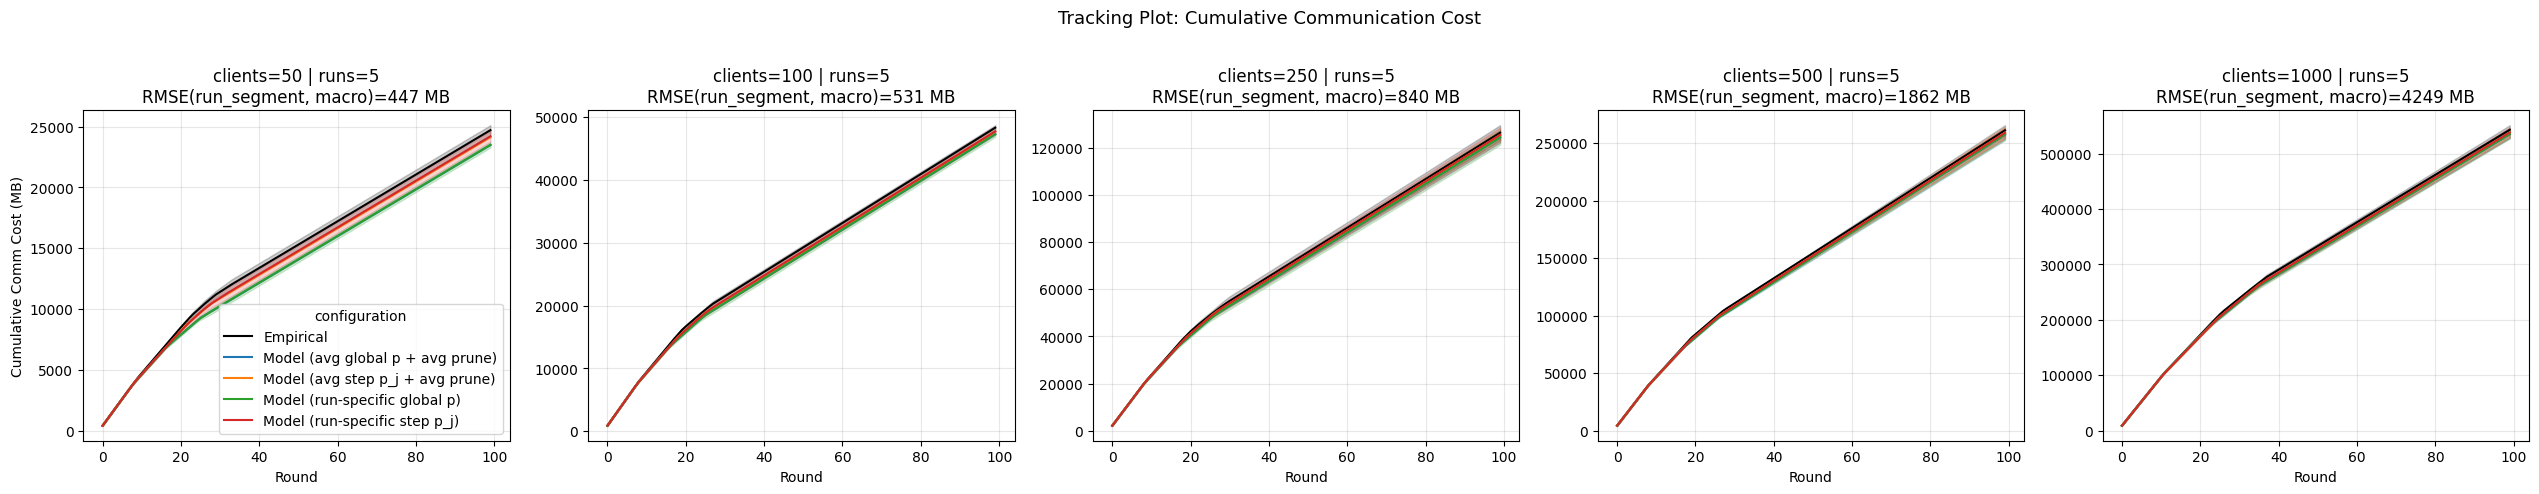

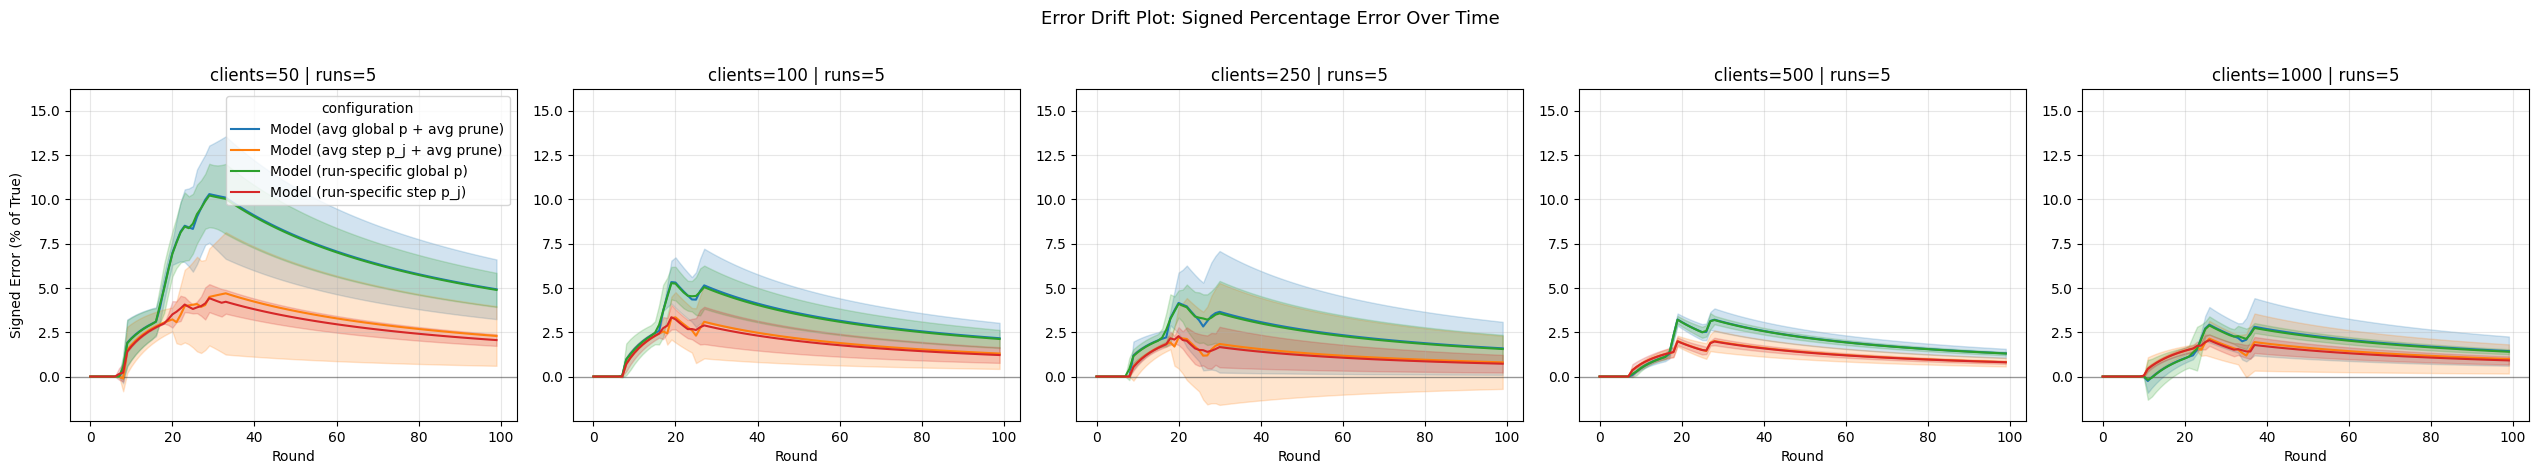

In [13]:
# Figure generation: cumulative cost and signed error with seaborn-managed confidence bands.
if "grouped_results" not in globals() or "validation" not in globals():
    raise RuntimeError("Run the previous analysis cell first to populate grouped validation variables.")

if grouped_results:
    ordered_groups = sorted(grouped_results, key=lambda result: int(result.total_clients))
    grouped_map = cmv._group_evaluated_results_by_total_clients(validation.results)

    cumulative_palette = {
        "Empirical": "black",
        CONFIG_LABELS["avg_global"]: "#1f77b4",
        CONFIG_LABELS["avg_segment"]: "#ff7f0e",
        CONFIG_LABELS["run_global"]: "#2ca02c",
        CONFIG_LABELS["run_segment"]: "#d62728",
    }
    error_palette = {
        CONFIG_LABELS["avg_global"]: "#1f77b4",
        CONFIG_LABELS["avg_segment"]: "#ff7f0e",
        CONFIG_LABELS["run_global"]: "#2ca02c",
        CONFIG_LABELS["run_segment"]: "#d62728",
    }

    # Figure A: cumulative tracking plots in one row ordered by total_clients.
    n_groups = len(ordered_groups)
    fig_cum, axes_cum = plt.subplots(1, n_groups, figsize=(5.1 * n_groups, 4.8), sharex=False)
    if n_groups == 1:
        axes_cum = [axes_cum]

    for idx, (axis, grouped_result) in enumerate(zip(axes_cum, ordered_groups)):
        group_results = grouped_map.get(int(grouped_result.total_clients), [])
        cumulative_df, _ = _build_seaborn_group_frames_for_group(
            group_results=group_results,
            gamma=GAMMA,
            rho=RHO,
            max_rounds=MAX_ROUNDS,
        )

        if cumulative_df.empty:
            axis.set_title(f"clients={grouped_result.total_clients} (no aligned rounds)")
            axis.axis("off")
            continue

        sns.lineplot(
            data=cumulative_df,
            x="round",
            y="value_mb",
            hue="configuration",
            errorbar=("sd"),
            sort=True,
            palette=cumulative_palette,
            ax=axis,
            legend="full" if idx == 0 else False,
        )

        rmse_macro = grouped_result.metrics_macro.get("run_segment", {}).get("rmse")
        rmse_macro_mb = _bits_to_mb_scalar(rmse_macro)

        axis.set_title(
            f"clients={grouped_result.total_clients} | runs={grouped_result.run_count}\n"
            f"RMSE(run_segment, macro)={rmse_macro_mb:.0f} MB"
        )
        axis.set_xlabel("Round")
        if idx == 0:
            axis.set_ylabel("Cumulative Comm Cost (MB)")
        else:
            axis.set_ylabel("")
        axis.grid(True, alpha=0.3)

    fig_cum.suptitle("Tracking Plot: Cumulative Communication Cost", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # Figure B: signed error plots in one row ordered by total_clients.
    fig_err, axes_err = plt.subplots(1, n_groups, figsize=(5.1 * n_groups, 4.6), sharex=False)
    if n_groups == 1:
        axes_err = [axes_err]

    prepared_error_by_clients = {}
    global_error_min = np.inf
    global_error_max = -np.inf

    for grouped_result in ordered_groups:
        group_results = grouped_map.get(int(grouped_result.total_clients), [])
        cumulative_df, error_df = _build_seaborn_group_frames_for_group(
            group_results=group_results,
            gamma=GAMMA,
            rho=RHO,
            max_rounds=MAX_ROUNDS,
        )

        if error_df.empty or cumulative_df.empty:
            continue

        empirical_per_round = (
            cumulative_df[cumulative_df["configuration"] == "Empirical"]
            .groupby("round", as_index=False)["value_mb"]
            .mean()
            .rename(columns={"value_mb": "empirical_mb"})
        )
        error_df = error_df.merge(empirical_per_round, on="round", how="left")
        error_df["value_pct"] = np.where(
            error_df["empirical_mb"].notna() & (~np.isclose(error_df["empirical_mb"], 0.0)),
            (error_df["value_mb"] / error_df["empirical_mb"]) * 100.0,
            np.nan,
        )

        valid_error_values = error_df["value_pct"].to_numpy(dtype=float)
        valid_error_values = valid_error_values[np.isfinite(valid_error_values)]
        if valid_error_values.size > 0:
            global_error_min = min(global_error_min, float(np.min(valid_error_values)))
            global_error_max = max(global_error_max, float(np.max(valid_error_values)))

        prepared_error_by_clients[int(grouped_result.total_clients)] = error_df

    shared_ylim = None
    if np.isfinite(global_error_min) and np.isfinite(global_error_max):
        if np.isclose(global_error_min, global_error_max):
            padding = max(1.0, abs(global_error_min) * 0.05)
            shared_ylim = (global_error_min - padding, global_error_max + padding)
        else:
            span = global_error_max - global_error_min
            padding = 0.05 * span
            shared_ylim = (global_error_min - padding, global_error_max + padding)

    for idx, (axis, grouped_result) in enumerate(zip(axes_err, ordered_groups)):
        total_clients = int(grouped_result.total_clients)
        error_df = prepared_error_by_clients.get(total_clients)

        if error_df is None or error_df.empty:
            axis.set_title(f"clients={grouped_result.total_clients} (no signed-error curves)")
            axis.axis("off")
            continue

        axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.35)
        sns.lineplot(
            data=error_df,
            x="round",
            y="value_pct",
            hue="configuration",
            errorbar=("sd"),
            sort=True,
            palette=error_palette,
            ax=axis,
            legend="full" if idx == 0 else False,
        )

        if shared_ylim is not None:
            axis.set_ylim(*shared_ylim)

        axis.set_title(f"clients={grouped_result.total_clients} | runs={grouped_result.run_count}")
        axis.set_xlabel("Round")
        if idx == 0:
            axis.set_ylabel("Signed Error (% of True)")
        else:
            axis.set_ylabel("")
        axis.grid(True, alpha=0.3)

    fig_err.suptitle("Error Drift Plot: Signed Percentage Error Over Time", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No grouped results available. Check skip reasons above.")

In [8]:
# Consolidation-timing precision analysis grouped by total_clients
if "grouped_validation" not in globals():
    raise RuntimeError("Run the previous analysis cell first to populate `grouped_validation`.")

timing_rows = cmv.build_grouped_consolidation_timing_rows(grouped_validation)
timing_df = pd.DataFrame(timing_rows)

if not timing_df.empty:
    # Keep only macro aggregation in output tables.
    timing_df = timing_df[timing_df["aggregation"] == "macro"].copy()

    timing_model_order = ["avg_global", "run_global", "avg_segment", "run_segment"]
    timing_df["model"] = pd.Categorical(
        timing_df["model"],
        categories=timing_model_order,
        ordered=True,
    )
    timing_df["aggregation"] = pd.Categorical(
        timing_df["aggregation"],
        categories=["macro"],
        ordered=True,
    )
    timing_df = (
        timing_df.sort_values(["total_clients", "model", "aggregation"])
        .reset_index(drop=True)
        .drop(columns=["aggregation", "rmse_rounds", "mean_bias_rounds", "runs_count", "events_count"])
    )


print("Consolidation timing precision (round error), grouped by total_clients, macro only")
display(timing_df)

# for _, timing_row in timing_df.iterrows():
#     print(
#         f"clients={int(timing_row['total_clients'])} | "
#         f"{timing_row['model']} | {timing_row['aggregation']} | "
#         f"MAE={timing_row['mae_rounds']:.3g} rounds | "
#         f"RMSE={timing_row['rmse_rounds']:.3g} rounds | "
#         f"Bias={timing_row['mean_bias_rounds']:.3g} rounds | "
#         f"runs={int(timing_row['runs_count'])}, events={int(timing_row['events_count'])}"
#     )

os.makedirs("plots", exist_ok=True)
latex_path_timing = "plots/costmodel_timing_precision_grouped.tex"
latex_table_timing = timing_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")

with open(latex_path_timing, "w", encoding="utf-8") as file_handle:
    file_handle.write(latex_table_timing)

print(f"Timing precision LaTeX table saved to: {latex_path_timing}")

Consolidation timing precision (round error), grouped by total_clients, macro only


,total_clients,model,mae_rounds
0,50,avg_global,4.973724
1,50,run_global,4.937740
2,50,avg_segment,2.404137
3,50,run_segment,2.124101
4,100,avg_global,2.600083
5,100,run_global,2.559143
6,100,avg_segment,1.769964
7,100,run_segment,1.665695
8,250,avg_global,2.598689
9,250,run_global,2.543992


Timing precision LaTeX table saved to: plots/costmodel_timing_precision_grouped.tex


In [9]:
# Fixed-pruning analysis grouped by total_clients: force pruning ratio to 0.1 per step (0.3 total for GAMMA=3)
if "grouped_validation" not in globals():
    raise RuntimeError("Run the grouped analysis cell first to populate `grouped_validation`.")

FIXED_PRUNE_RATIO_TOTAL = 0.3
FIXED_PRUNE_RATIO_PER_STEP = FIXED_PRUNE_RATIO_TOTAL / GAMMA
MB_FACTOR_BITS = 8.0 * 1024.0 * 1024.0

print(
    f"Running grouped fixed-pruning analysis with per-step={FIXED_PRUNE_RATIO_PER_STEP:.3f}, "
    f"total={FIXED_PRUNE_RATIO_TOTAL:.3f}"
)

grouped_map = cmv._group_evaluated_results_by_total_clients(grouped_validation.base_validation.results)
fixed_prune_rows = []

for total_clients in sorted(grouped_map):
    group_results = grouped_map[total_clients]

    per_run_rounds = []
    per_run_actual = []
    per_run_pred_avg_global = []
    per_run_pred_run_global = []
    per_run_pred_avg_segment = []
    per_run_pred_run_segment = []
    per_run_segment_indices = []

    # Compute group averages
    average_global_probability = cmv._safe_group_average(
        [result.global_probability for result in group_results],
    )
    average_step_probabilities = cmv._average_step_probabilities(
        group_results,
        grouped_validation.gamma,
    )

    for result in group_results:
        if not result.rounds or not result.actual_cumulative_cost:
            continue
        if result.total_clients is None or result.clients_per_round is None:
            continue
        if result.initial_model_size_bits is None:
            continue
        if result.global_probability is None or len(result.step_probabilities) != GAMMA:
            continue

        # avg_global: using group average global probability
        pred_avg_global_fixed = cmv._predict_cumulative_cost(
            rounds=result.rounds,
            total_clients=int(result.total_clients),
            clients_per_round=int(result.clients_per_round),
            initial_model_size_bits=float(result.initial_model_size_bits),
            prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
            gamma=GAMMA,
            rho=RHO,
            global_p=float(average_global_probability)
            if average_global_probability is not None
            else float(result.global_probability),
            prune_correction="quadratic",
        )

        # run_global: using run-specific global probability
        pred_run_global_fixed = cmv._predict_cumulative_cost(
            rounds=result.rounds,
            total_clients=int(result.total_clients),
            clients_per_round=int(result.clients_per_round),
            initial_model_size_bits=float(result.initial_model_size_bits),
            prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
            gamma=GAMMA,
            rho=RHO,
            global_p=float(result.global_probability),
            prune_correction="quadratic",
        )

        # avg_segment: using group average step probabilities
        pred_avg_segment_fixed = cmv._predict_cumulative_cost(
            rounds=result.rounds,
            total_clients=int(result.total_clients),
            clients_per_round=int(result.clients_per_round),
            initial_model_size_bits=float(result.initial_model_size_bits),
            prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
            gamma=GAMMA,
            rho=RHO,
            p_steps=average_step_probabilities,
            prune_correction="quadratic",
        )

        # run_segment: using run-specific step probabilities
        pred_run_segment_fixed = cmv._predict_cumulative_cost(
            rounds=result.rounds,
            total_clients=int(result.total_clients),
            clients_per_round=int(result.clients_per_round),
            initial_model_size_bits=float(result.initial_model_size_bits),
            prune_ratio=FIXED_PRUNE_RATIO_TOTAL,
            gamma=GAMMA,
            rho=RHO,
            p_steps=[float(p_value) for p_value in result.step_probabilities],
            prune_correction="quadratic",
        )

        per_run_rounds.append([int(round_value) for round_value in result.rounds])
        per_run_actual.append(np.array(result.actual_cumulative_cost, dtype=float))
        per_run_pred_avg_global.append(np.array(pred_avg_global_fixed, dtype=float))
        per_run_pred_run_global.append(np.array(pred_run_global_fixed, dtype=float))
        per_run_pred_avg_segment.append(np.array(pred_avg_segment_fixed, dtype=float))
        per_run_pred_run_segment.append(np.array(pred_run_segment_fixed, dtype=float))
        per_run_segment_indices.append(cmv._build_segment_indices(result.rounds, result.drop_rounds))

    if len(per_run_actual) == 0:
        continue

    _, aligned_actual, actual_err = cmv._align_group_curves(
        rounds_list=per_run_rounds,
        curves_list=[curve.tolist() for curve in per_run_actual],
        max_rounds=MAX_ROUNDS,
    )
    _, aligned_pred_avg_global, avg_global_err = cmv._align_group_curves(
        rounds_list=per_run_rounds,
        curves_list=[curve.tolist() for curve in per_run_pred_avg_global],
        max_rounds=MAX_ROUNDS,
    )
    _, aligned_pred_run_global, run_global_err = cmv._align_group_curves(
        rounds_list=per_run_rounds,
        curves_list=[curve.tolist() for curve in per_run_pred_run_global],
        max_rounds=MAX_ROUNDS,
    )
    _, aligned_pred_avg_segment, avg_segment_err = cmv._align_group_curves(
        rounds_list=per_run_rounds,
        curves_list=[curve.tolist() for curve in per_run_pred_avg_segment],
        max_rounds=MAX_ROUNDS,
    )
    _, aligned_pred_run_segment, run_segment_err = cmv._align_group_curves(
        rounds_list=per_run_rounds,
        curves_list=[curve.tolist() for curve in per_run_pred_run_segment],
        max_rounds=MAX_ROUNDS,
    )

    if (
        actual_err is not None
        or avg_global_err is not None
        or run_global_err is not None
        or avg_segment_err is not None
        or run_segment_err is not None
    ):
        print(f"Skipping clients={total_clients} due to alignment error")
        continue

    horizon = aligned_actual.shape[1]
    aligned_segment_indices = [indices[:horizon] for indices in per_run_segment_indices]

    metrics_avg_global_macro, _ = cmv._compute_group_metrics(
        actual_curves=aligned_actual,
        predicted_curves=aligned_pred_avg_global,
        segment_indices_per_run=aligned_segment_indices,
        segment_count=GAMMA + 1,
    )
    metrics_run_global_macro, _ = cmv._compute_group_metrics(
        actual_curves=aligned_actual,
        predicted_curves=aligned_pred_run_global,
        segment_indices_per_run=aligned_segment_indices,
        segment_count=GAMMA + 1,
    )
    metrics_avg_segment_macro, _ = cmv._compute_group_metrics(
        actual_curves=aligned_actual,
        predicted_curves=aligned_pred_avg_segment,
        segment_indices_per_run=aligned_segment_indices,
        segment_count=GAMMA + 1,
    )
    metrics_run_segment_macro, _ = cmv._compute_group_metrics(
        actual_curves=aligned_actual,
        predicted_curves=aligned_pred_run_segment,
        segment_indices_per_run=aligned_segment_indices,
        segment_count=GAMMA + 1,
    )

    avg_data_prune = float(np.mean([result.prune_ratio for result in group_results if result.prune_ratio is not None]))

    empirical_total_cost_mb = float(np.mean(aligned_actual[:, -1]) / MB_FACTOR_BITS)
    pred_avg_global_total_cost_mb = float(np.mean(aligned_pred_avg_global[:, -1]) / MB_FACTOR_BITS)
    pred_run_global_total_cost_mb = float(np.mean(aligned_pred_run_global[:, -1]) / MB_FACTOR_BITS)
    pred_avg_segment_total_cost_mb = float(np.mean(aligned_pred_avg_segment[:, -1]) / MB_FACTOR_BITS)
    pred_run_segment_total_cost_mb = float(np.mean(aligned_pred_run_segment[:, -1]) / MB_FACTOR_BITS)

    # Create rows for all four model configurations
    fixed_prune_rows.append(
        {
            "total_clients": total_clients,
            "run_count": len(group_results),
            "aggregation": "macro",
            "model": "avg_global",
            "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "avg_data_prune_ratio_total": avg_data_prune,
            "mae_mb": float(metrics_avg_global_macro.get("mae", np.nan)) / MB_FACTOR_BITS,
            "rmse_mb": float(metrics_avg_global_macro.get("rmse", np.nan)) / MB_FACTOR_BITS,
            "mean_bias_mb": float(metrics_avg_global_macro.get("mean_bias", np.nan)) / MB_FACTOR_BITS,
            "mape_percent": metrics_avg_global_macro.get("mape_percent"),
            "smape_percent": metrics_avg_global_macro.get("smape_percent"),
            "r2": metrics_avg_global_macro.get("r2"),
            "final_bias_percent": metrics_avg_global_macro.get("final_bias_percent"),
            "empirical_total_cost_mb": empirical_total_cost_mb,
            "predicted_total_cost_mb": pred_avg_global_total_cost_mb,
            "absolute_total_error_mb": abs(pred_avg_global_total_cost_mb - empirical_total_cost_mb),
        }
    )
    fixed_prune_rows.append(
        {
            "total_clients": total_clients,
            "run_count": len(group_results),
            "aggregation": "macro",
            "model": "run_global",
            "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "avg_data_prune_ratio_total": avg_data_prune,
            "mae_mb": float(metrics_run_global_macro.get("mae", np.nan)) / MB_FACTOR_BITS,
            "rmse_mb": float(metrics_run_global_macro.get("rmse", np.nan)) / MB_FACTOR_BITS,
            "mean_bias_mb": float(metrics_run_global_macro.get("mean_bias", np.nan)) / MB_FACTOR_BITS,
            "mape_percent": metrics_run_global_macro.get("mape_percent"),
            "smape_percent": metrics_run_global_macro.get("smape_percent"),
            "r2": metrics_run_global_macro.get("r2"),
            "final_bias_percent": metrics_run_global_macro.get("final_bias_percent"),
            "empirical_total_cost_mb": empirical_total_cost_mb,
            "predicted_total_cost_mb": pred_run_global_total_cost_mb,
            "absolute_total_error_mb": abs(pred_run_global_total_cost_mb - empirical_total_cost_mb),
        }
    )
    fixed_prune_rows.append(
        {
            "total_clients": total_clients,
            "run_count": len(group_results),
            "aggregation": "macro",
            "model": "avg_segment",
            "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "avg_data_prune_ratio_total": avg_data_prune,
            "mae_mb": float(metrics_avg_segment_macro.get("mae", np.nan)) / MB_FACTOR_BITS,
            "rmse_mb": float(metrics_avg_segment_macro.get("rmse", np.nan)) / MB_FACTOR_BITS,
            "mean_bias_mb": float(metrics_avg_segment_macro.get("mean_bias", np.nan)) / MB_FACTOR_BITS,
            "mape_percent": metrics_avg_segment_macro.get("mape_percent"),
            "smape_percent": metrics_avg_segment_macro.get("smape_percent"),
            "r2": metrics_avg_segment_macro.get("r2"),
            "final_bias_percent": metrics_avg_segment_macro.get("final_bias_percent"),
            "empirical_total_cost_mb": empirical_total_cost_mb,
            "predicted_total_cost_mb": pred_avg_segment_total_cost_mb,
            "absolute_total_error_mb": abs(pred_avg_segment_total_cost_mb - empirical_total_cost_mb),
        }
    )
    fixed_prune_rows.append(
        {
            "total_clients": total_clients,
            "run_count": len(group_results),
            "aggregation": "macro",
            "model": "run_segment",
            "fixed_prune_ratio_total": FIXED_PRUNE_RATIO_TOTAL,
            "avg_data_prune_ratio_total": avg_data_prune,
            "mae_mb": float(metrics_run_segment_macro.get("mae", np.nan)) / MB_FACTOR_BITS,
            "rmse_mb": float(metrics_run_segment_macro.get("rmse", np.nan)) / MB_FACTOR_BITS,
            "mean_bias_mb": float(metrics_run_segment_macro.get("mean_bias", np.nan)) / MB_FACTOR_BITS,
            "mape_percent": metrics_run_segment_macro.get("mape_percent"),
            "smape_percent": metrics_run_segment_macro.get("smape_percent"),
            "r2": metrics_run_segment_macro.get("r2"),
            "final_bias_percent": metrics_run_segment_macro.get("final_bias_percent"),
            "empirical_total_cost_mb": empirical_total_cost_mb,
            "predicted_total_cost_mb": pred_run_segment_total_cost_mb,
            "absolute_total_error_mb": abs(pred_run_segment_total_cost_mb - empirical_total_cost_mb),
        }
    )

fixed_prune_df = pd.DataFrame(fixed_prune_rows)

if fixed_prune_df.empty:
    print("No grouped evaluated runs available for fixed-pruning analysis.")
else:
    fixed_prune_df["model"] = pd.Categorical(
        fixed_prune_df["model"],
        categories=["avg_global", "run_global", "avg_segment", "run_segment"],
        ordered=True,
    )
    fixed_prune_df["aggregation"] = pd.Categorical(
        fixed_prune_df["aggregation"],
        categories=["macro"],
        ordered=True,
    )
    fixed_prune_df = (
        fixed_prune_df.sort_values(["total_clients", "model", "aggregation"])
        .reset_index(drop=True)
        .drop(
            columns=[
                "run_count",
                "aggregation",
                "fixed_prune_ratio_total",
                "rmse_mb",
                "mean_bias_mb",
                "final_bias_percent",
                "empirical_total_cost_mb",
                "predicted_total_cost_mb",
                "absolute_total_error_mb",
            ]
        )
    )

    print("Grouped fixed-pruning cost-model metrics (macro only, MB units)")
    display(fixed_prune_df)

    os.makedirs("plots", exist_ok=True)
    latex_path_fixed_prune = "plots/costmodel_metrics_fixed_prune_grouped.tex"
    latex_table_fixed_prune = fixed_prune_df.to_latex(index=False, float_format=lambda value: f"{value:.4g}")

    with open(latex_path_fixed_prune, "w", encoding="utf-8") as file_handle:
        file_handle.write(latex_table_fixed_prune)

    print(f"Grouped fixed-pruning LaTeX table saved to: {latex_path_fixed_prune}")


Running grouped fixed-pruning analysis with per-step=0.100, total=0.300
Grouped fixed-pruning cost-model metrics (macro only, MB units)


,total_clients,model,avg_data_prune_ratio_total,mae_mb,mape_percent,smape_percent,r2
0,50,avg_global,0.564300,472.923137,3.440150,3.535459,0.991649
1,50,run_global,0.564300,436.115050,3.263660,3.351487,0.992994
2,50,avg_segment,0.564300,455.288257,2.787781,2.780843,0.991458
3,50,run_segment,0.564300,415.549996,2.486086,2.474411,0.993155
4,100,avg_global,0.557847,787.940926,2.536697,2.533757,0.993601
5,100,run_global,0.557847,770.676150,2.460170,2.457067,0.993954
6,100,avg_segment,0.557847,901.269258,2.667922,2.636469,0.991077
7,100,run_segment,0.557847,892.324434,2.594432,2.563205,0.991338
8,250,avg_global,0.530921,1849.332093,2.459383,2.494632,0.995519
9,250,run_global,0.530921,1336.802081,1.922500,1.947534,0.997759


Grouped fixed-pruning LaTeX table saved to: plots/costmodel_metrics_fixed_prune_grouped.tex


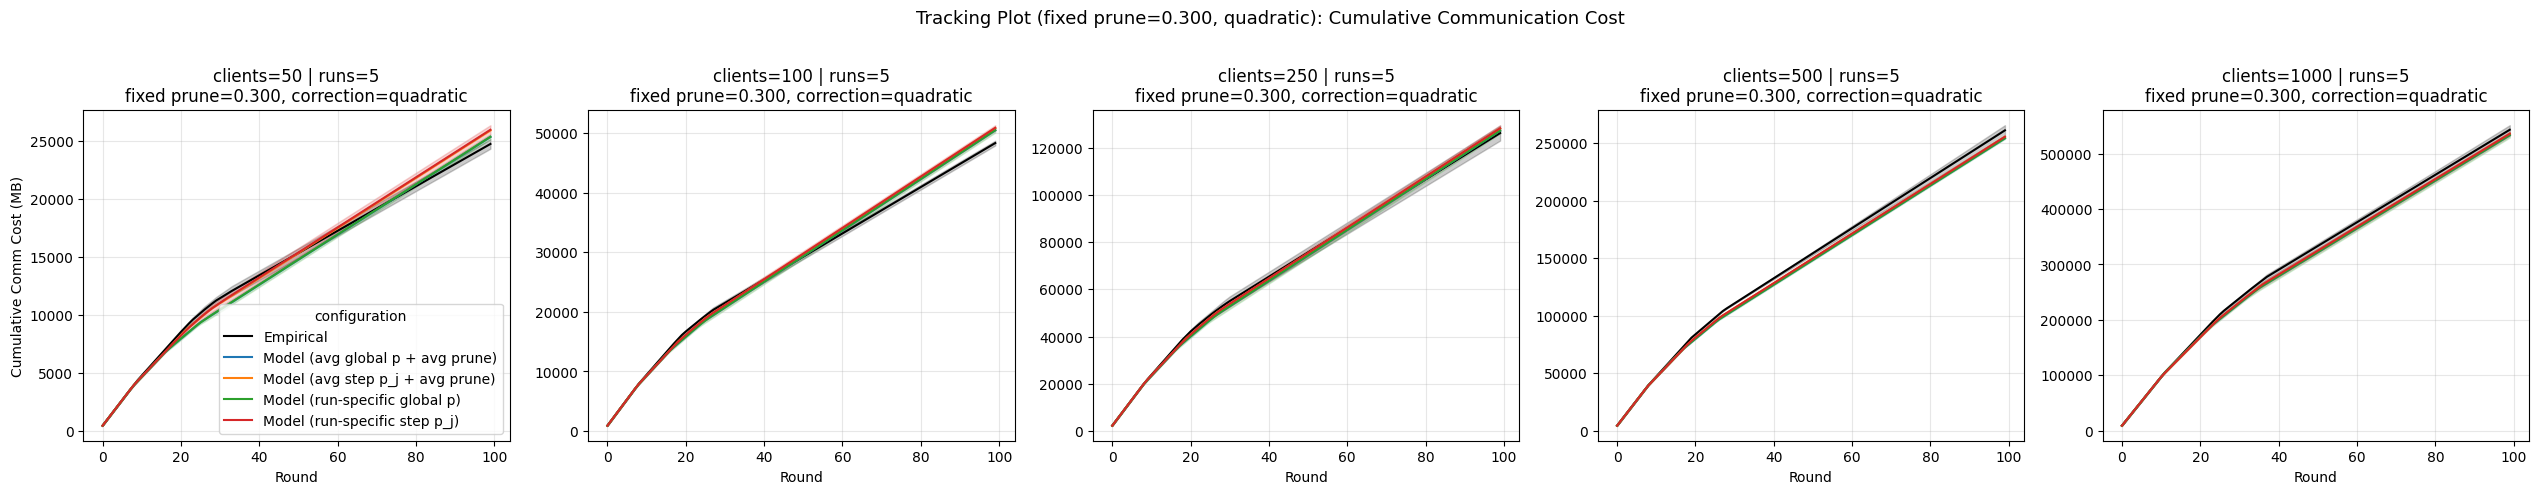

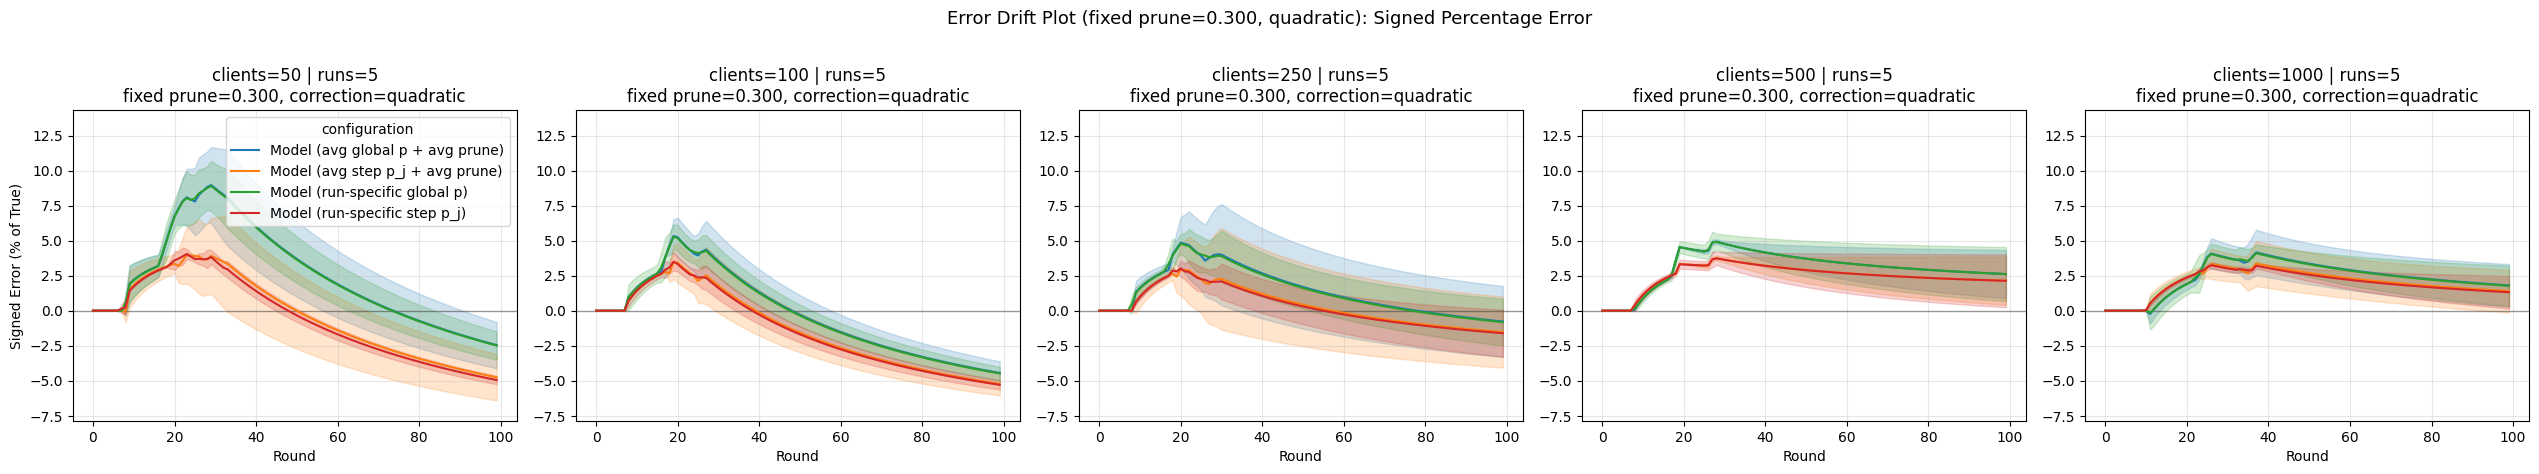

In [16]:
# Fixed-pruning figure generation: cumulative cost and signed percentage error.
if "grouped_validation" not in globals():
    raise RuntimeError("Run the grouped analysis cell first to populate `grouped_validation`.")
if "FIXED_PRUNE_RATIO_TOTAL" not in globals():
    raise RuntimeError("Run Cell 7 first to populate `FIXED_PRUNE_RATIO_TOTAL`.")

fixed_prune_ratio_total = float(FIXED_PRUNE_RATIO_TOTAL)
ordered_groups = sorted(grouped_validation.grouped_results, key=lambda result: int(result.total_clients))
grouped_map = cmv._group_evaluated_results_by_total_clients(grouped_validation.base_validation.results)

cumulative_palette = {
    "Empirical": "black",
    CONFIG_LABELS["avg_global"]: "#1f77b4",
    CONFIG_LABELS["avg_segment"]: "#ff7f0e",
    CONFIG_LABELS["run_global"]: "#2ca02c",
    CONFIG_LABELS["run_segment"]: "#d62728",
}
error_palette = {
    CONFIG_LABELS["avg_global"]: "#1f77b4",
    CONFIG_LABELS["avg_segment"]: "#ff7f0e",
    CONFIG_LABELS["run_global"]: "#2ca02c",
    CONFIG_LABELS["run_segment"]: "#d62728",
}


def _build_fixed_prune_group_frames_for_group(group_results, gamma, rho, max_rounds, fixed_prune_ratio):
    avg_global_probability = cmv._safe_group_average([result.global_probability for result in group_results])
    avg_step_probabilities = cmv._average_step_probabilities(group_results, gamma=gamma)

    config_params = {
        "avg_global": {
            "display": CONFIG_LABELS["avg_global"],
            "mode": "global",
            "probability": avg_global_probability,
        },
        "avg_segment": {
            "display": CONFIG_LABELS["avg_segment"],
            "mode": "steps",
            "probability": avg_step_probabilities if len(avg_step_probabilities) == gamma else None,
        },
        "run_global": {
            "display": CONFIG_LABELS["run_global"],
            "mode": "global_run",
            "probability": None,
        },
        "run_segment": {
            "display": CONFIG_LABELS["run_segment"],
            "mode": "steps_run",
            "probability": None,
        },
    }

    cumulative_rows = []
    error_rows = []

    rounds_list = [result.rounds for result in group_results if len(result.rounds) > 0]
    empirical_curves_list = [
        result.actual_cumulative_cost for result in group_results if len(result.actual_cumulative_cost) > 0
    ]
    if len(rounds_list) > 0 and len(empirical_curves_list) > 0:
        aligned_rounds, aligned_empirical, align_error = cmv._align_group_curves(
            rounds_list=rounds_list,
            curves_list=empirical_curves_list,
            max_rounds=max_rounds,
        )
        if align_error is None:
            for run_idx, empirical_curve in enumerate(aligned_empirical):
                run_id = f"empirical_{run_idx}"
                for round_value, actual_bits in zip(aligned_rounds, empirical_curve):
                    cumulative_rows.append(
                        {
                            "round": int(round_value),
                            "value_mb": float(actual_bits) / MB_FACTOR_BITS,
                            "configuration": "Empirical",
                            "run_id": run_id,
                        }
                    )

    for config_name, config in config_params.items():
        per_run_predictions = []
        per_run_actuals = []
        per_run_rounds = []

        for result in group_results:
            if len(result.actual_cumulative_cost) == 0 or len(result.rounds) == 0:
                continue
            if result.total_clients is None or result.clients_per_round is None:
                continue
            if result.initial_model_size_bits is None:
                continue

            prediction_args = {
                "rounds": result.rounds,
                "total_clients": int(result.total_clients),
                "clients_per_round": int(result.clients_per_round),
                "initial_model_size_bits": float(result.initial_model_size_bits),
                "prune_ratio": fixed_prune_ratio,
                "gamma": gamma,
                "rho": rho,
                "prune_correction": "quadratic",
            }

            if config["mode"] == "global":
                if config["probability"] is None:
                    continue
                predicted = cmv._predict_cumulative_cost(
                    **prediction_args,
                    global_p=float(config["probability"]),
                )
            elif config["mode"] == "global_run":
                if result.global_probability is None:
                    continue
                predicted = cmv._predict_cumulative_cost(
                    **prediction_args,
                    global_p=float(result.global_probability),
                )
            elif config["mode"] == "steps":
                step_probabilities = config["probability"]
                if step_probabilities is None or len(step_probabilities) != gamma:
                    continue
                predicted = cmv._predict_cumulative_cost(
                    **prediction_args,
                    p_steps=[float(p_value) for p_value in step_probabilities],
                )
            else:
                step_probabilities = result.step_probabilities
                if step_probabilities is None or len(step_probabilities) != gamma:
                    continue
                predicted = cmv._predict_cumulative_cost(
                    **prediction_args,
                    p_steps=[float(p_value) for p_value in step_probabilities],
                )

            per_run_predictions.append(np.array(predicted, dtype=float))
            per_run_actuals.append(np.array(result.actual_cumulative_cost, dtype=float))
            per_run_rounds.append([int(round_value) for round_value in result.rounds])

        if len(per_run_predictions) == 0:
            continue

        aligned_rounds, aligned_actual, align_error = cmv._align_group_curves(
            rounds_list=per_run_rounds,
            curves_list=[actual.tolist() for actual in per_run_actuals],
            max_rounds=max_rounds,
        )
        if align_error is not None:
            continue

        _, aligned_predictions, pred_align_error = cmv._align_group_curves(
            rounds_list=per_run_rounds,
            curves_list=[prediction.tolist() for prediction in per_run_predictions],
            max_rounds=max_rounds,
        )
        if pred_align_error is not None:
            continue

        for run_idx, (actual_curve, predicted_curve) in enumerate(zip(aligned_actual, aligned_predictions)):
            run_id = f"{config_name}_{run_idx}"
            for round_value, actual_bits, predicted_bits in zip(aligned_rounds, actual_curve, predicted_curve):
                cumulative_rows.append(
                    {
                        "round": int(round_value),
                        "value_mb": float(predicted_bits) / MB_FACTOR_BITS,
                        "configuration": config["display"],
                        "run_id": run_id,
                    }
                )
                error_rows.append(
                    {
                        "round": int(round_value),
                        "value_mb": (float(actual_bits) - float(predicted_bits)) / MB_FACTOR_BITS,
                        "configuration": config["display"],
                        "run_id": run_id,
                    }
                )

    cumulative_df = pd.DataFrame(cumulative_rows)
    error_df = pd.DataFrame(error_rows)
    return cumulative_df, error_df


if ordered_groups:
    # Figure A: cumulative tracking plots with fixed pruning and quadratic correction.
    n_groups = len(ordered_groups)
    fig_cum, axes_cum = plt.subplots(1, n_groups, figsize=(5.1 * n_groups, 4.8), sharex=False)
    if n_groups == 1:
        axes_cum = [axes_cum]

    for idx, (axis, grouped_result) in enumerate(zip(axes_cum, ordered_groups)):
        group_results = grouped_map.get(int(grouped_result.total_clients), [])
        cumulative_df, _ = _build_fixed_prune_group_frames_for_group(
            group_results=group_results,
            gamma=GAMMA,
            rho=RHO,
            max_rounds=MAX_ROUNDS,
            fixed_prune_ratio=fixed_prune_ratio_total,
        )

        if cumulative_df.empty:
            axis.set_title(f"clients={grouped_result.total_clients} (no aligned rounds)")
            axis.axis("off")
            continue

        sns.lineplot(
            data=cumulative_df,
            x="round",
            y="value_mb",
            hue="configuration",
            errorbar=("sd"),
            sort=True,
            palette=cumulative_palette,
            ax=axis,
            legend="full" if idx == 0 else False,
        )

        axis.set_title(
            f"clients={grouped_result.total_clients} | runs={grouped_result.run_count}\n"
            f"fixed prune={fixed_prune_ratio_total:.3f}, correction=quadratic"
        )
        axis.set_xlabel("Round")
        if idx == 0:
            axis.set_ylabel("Cumulative Comm Cost (MB)")
        else:
            axis.set_ylabel("")
        axis.grid(True, alpha=0.3)

    fig_cum.suptitle(
        f"Tracking Plot (fixed prune={fixed_prune_ratio_total:.3f}, quadratic): Cumulative Communication Cost",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

    # Figure B: signed percentage error plots with shared y-limits.
    fig_err, axes_err = plt.subplots(1, n_groups, figsize=(5.1 * n_groups, 4.6), sharex=False)
    if n_groups == 1:
        axes_err = [axes_err]

    prepared_error_by_clients = {}
    global_error_min = np.inf
    global_error_max = -np.inf

    for grouped_result in ordered_groups:
        group_results = grouped_map.get(int(grouped_result.total_clients), [])
        cumulative_df, error_df = _build_fixed_prune_group_frames_for_group(
            group_results=group_results,
            gamma=GAMMA,
            rho=RHO,
            max_rounds=MAX_ROUNDS,
            fixed_prune_ratio=fixed_prune_ratio_total,
        )

        if error_df.empty or cumulative_df.empty:
            continue

        empirical_per_round = (
            cumulative_df[cumulative_df["configuration"] == "Empirical"]
            .groupby("round", as_index=False)["value_mb"]
            .mean()
            .rename(columns={"value_mb": "empirical_mb"})
        )
        error_df = error_df.merge(empirical_per_round, on="round", how="left")
        error_df["value_pct"] = np.where(
            error_df["empirical_mb"].notna() & (~np.isclose(error_df["empirical_mb"], 0.0)),
            (error_df["value_mb"] / error_df["empirical_mb"]) * 100.0,
            np.nan,
        )

        valid_error_values = error_df["value_pct"].to_numpy(dtype=float)
        valid_error_values = valid_error_values[np.isfinite(valid_error_values)]
        if valid_error_values.size > 0:
            global_error_min = min(global_error_min, float(np.min(valid_error_values)))
            global_error_max = max(global_error_max, float(np.max(valid_error_values)))

        prepared_error_by_clients[int(grouped_result.total_clients)] = error_df

    shared_ylim = None
    if np.isfinite(global_error_min) and np.isfinite(global_error_max):
        if np.isclose(global_error_min, global_error_max):
            padding = max(1.0, abs(global_error_min) * 0.05)
            shared_ylim = (global_error_min - padding, global_error_max + padding)
        else:
            span = global_error_max - global_error_min
            padding = 0.05 * span
            shared_ylim = (global_error_min - padding, global_error_max + padding)

    for idx, (axis, grouped_result) in enumerate(zip(axes_err, ordered_groups)):
        total_clients = int(grouped_result.total_clients)
        error_df = prepared_error_by_clients.get(total_clients)

        if error_df is None or error_df.empty:
            axis.set_title(f"clients={grouped_result.total_clients} (no signed-error curves)")
            axis.axis("off")
            continue

        axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.35)
        sns.lineplot(
            data=error_df,
            x="round",
            y="value_pct",
            hue="configuration",
            errorbar=("sd"),
            sort=True,
            palette=error_palette,
            ax=axis,
            legend="full" if idx == 0 else False,
        )

        if shared_ylim is not None:
            axis.set_ylim(*shared_ylim)

        axis.set_title(
            f"clients={grouped_result.total_clients} | runs={grouped_result.run_count}\n"
            f"fixed prune={fixed_prune_ratio_total:.3f}, correction=quadratic"
        )
        axis.set_xlabel("Round")
        if idx == 0:
            axis.set_ylabel("Signed Error (% of True)")
        else:
            axis.set_ylabel("")
        axis.grid(True, alpha=0.3)

    fig_err.suptitle(
        f"Error Drift Plot (fixed prune={fixed_prune_ratio_total:.3f}, quadratic): Signed Percentage Error",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No grouped results available. Check skip reasons above.")